## 1. Situation

We are given a tabular regression dataset with 10 float-valued input features per sample and a single continuous float target. The goal is to train a feed-forward neural network in PyTorch that predicts the target value from the 10 features. Model quality is evaluated using Mean Squared Error (`torch.nn.MSELoss()`) between predictions and true targets on held-out data. We select the best model based on validation MSE observed during training and report its performance on the test set.

## 2. Data description

* `X_train.csv` / `X_test.csv`: 700 samples x 10 features, no header row, no missing values.
* `y_train.csv` / `Y_test.csv`: 700 samples x 1 target value, no header row, no missing values.
* All 10 input features are already standardized (mean approx 0, std approx 1), roughly in the range [-4, 4].
* The target is also on a standardized-looking scale (mean approx 0, std approx 1), range approx [-3, 5.7].
* Because no further scaling is required, we feed the features directly into the network. We still carve out an internal validation split from the training data (80/20) to monitor generalization and perform model selection / early stopping, since that is the only way to get an honest generalization signal here.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
X_train_full = pd.read_csv("X_train.csv", header=None).values.astype(np.float32)
y_train_full = pd.read_csv("y_train.csv", header=None).values.astype(np.float32).reshape(-1, 1)
X_test = pd.read_csv("X_test.csv", header=None).values.astype(np.float32)
y_test = pd.read_csv("Y_test.csv", header=None).values.astype(np.float32).reshape(-1, 1)

print("X_train_full:", X_train_full.shape, "y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train_full: (700, 10) y_train_full: (700, 1)
X_test: (700, 10) y_test: (700, 1)


In [3]:
# Split off an internal validation set for model selection / early stopping.
n = X_train_full.shape[0]
rng = np.random.RandomState(SEED)
perm = rng.permutation(n)

n_val = int(0.2 * n)
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

print("train:", X_train.shape, "val:", X_val.shape)

train: (560, 10) val: (140, 10)


In [4]:
def to_tensor(arr):
    return torch.from_numpy(arr)

X_train_t, y_train_t = to_tensor(X_train), to_tensor(y_train)
X_val_t, y_val_t = to_tensor(X_val).to(device), to_tensor(y_val).to(device)
X_test_t, y_test_t = to_tensor(X_test).to(device), to_tensor(y_test).to(device)

BATCH_SIZE = 32
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

## 4. Model specification

A small fully-connected feed-forward network:

* Input layer: 10 features
* Hidden layer 1: Linear(10 -> 64) + ReLU + Dropout(0.1)
* Hidden layer 2: Linear(64 -> 32) + ReLU + Dropout(0.1)
* Hidden layer 3: Linear(32 -> 16) + ReLU
* Output layer: Linear(16 -> 1)

This is 4 `Linear` layers total (well under the 20-layer limit), which is enough capacity for a 10-feature tabular regression problem without overfitting a 700-row dataset. ReLU activations are used throughout the hidden layers, with light dropout (0.1) after the first two hidden layers for regularization; the output layer is linear (no activation) since this is unconstrained real-valued regression.

In [5]:
class RegressionNet(nn.Module):
    def __init__(self, in_features=10, hidden=(64, 32, 16), dropout=0.1):
        super().__init__()
        h1, h2, h3 = hidden
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x)

model = RegressionNet().to(device)
model

RegressionNet(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

## 5. Training specification

* Loss function: `torch.nn.MSELoss()` (as required by the evaluation constraint).
* Optimizer: Adam, learning rate 1e-3, weight decay 1e-4 (mild L2 regularization).
* Batch size: 32.
* Number of epochs: up to 500, with early stopping.
* Validation strategy: 80/20 split of the training data (see above); validation MSE computed once per epoch.
* Early stopping: training stops if validation MSE does not improve for 30 consecutive epochs (patience=30).
* Best model: the epoch with the lowest validation MSE; its parameters are saved into `best_model_state`.

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 500
PATIENCE = 30

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_model_state = None
best_epoch = -1
epochs_no_improve = 0

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_mse = running_loss / len(train_ds)

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_mse = criterion(val_preds, y_val_t).item()

    train_losses.append(train_mse)
    val_losses.append(val_mse)

    if val_mse < best_val_loss:
        best_val_loss = val_mse
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE {train_mse:.4f} | val MSE {val_mse:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best val MSE: {best_val_loss:.4f})")
        break

print(f"\nBest epoch: {best_epoch}, best validation MSE: {best_val_loss:.4f}")

Epoch    1 | train MSE 1.0212 | val MSE 1.0464
Epoch   20 | train MSE 0.1641 | val MSE 0.1780
Epoch   40 | train MSE 0.1152 | val MSE 0.1476
Epoch   60 | train MSE 0.0756 | val MSE 0.1411
Epoch   80 | train MSE 0.0830 | val MSE 0.1322
Epoch  100 | train MSE 0.0764 | val MSE 0.1300
Early stopping at epoch 113 (best epoch: 83, best val MSE: 0.1226)

Best epoch: 83, best validation MSE: 0.1226


## 6. Training curve

Train and validation MSE recorded per epoch, plotted below.

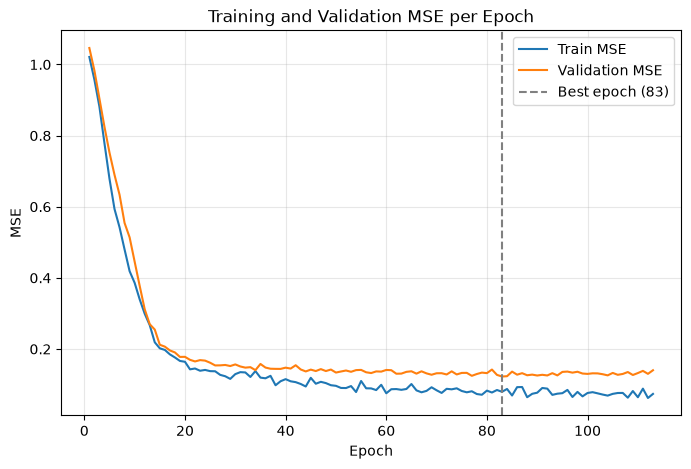

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train MSE")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation MSE")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation MSE per Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Final evaluation on test set

Load `best_model_state` (lowest validation MSE) and evaluate on the held-out test set using `torch.nn.MSELoss()`.

In [8]:
best_model = RegressionNet().to(device)
best_model.load_state_dict(best_model_state)
best_model.eval()

with torch.no_grad():
    test_preds = best_model(X_test_t)
    test_mse = criterion(test_preds, y_test_t).item()

print(f"Test MSE (torch.nn.MSELoss): {test_mse:.4f}")

Test MSE (torch.nn.MSELoss): 0.0519
